## Benchmarks for models

In [5]:
import json, re, os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

BASE = Path("dataset/eval_reports")
FILES = [
    "google_gemma-3-270m-it-inference-evaluation.json",
    "google_gemma-3-270m-it-inference-evaluation-gpu.json",
    "google_medgemma-4b-it-inference-gpu-evaluation.json",
]

In [6]:
runs = []
for fn in FILES:
    fp = BASE / fn
    with open(fp, "r") as f:
        data = json.load(f)
    data["_name"] = fn  # use filename as label
    runs.append(data)

In [7]:
def parse_classification_report(text: str) -> pd.DataFrame:
    rows = []
    for line in text.strip().splitlines():
        m = re.match(r"\s*([A-Za-z0-9_\-]+)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9]+)", line)
        if m:
            label, prec, rec, f1, supp = m.groups()
            rows.append({
                "label": label,
                "precision": float(prec),
                "recall": float(rec),
                "f1": float(f1),
                "support": int(supp)
            })
    return pd.DataFrame(rows)

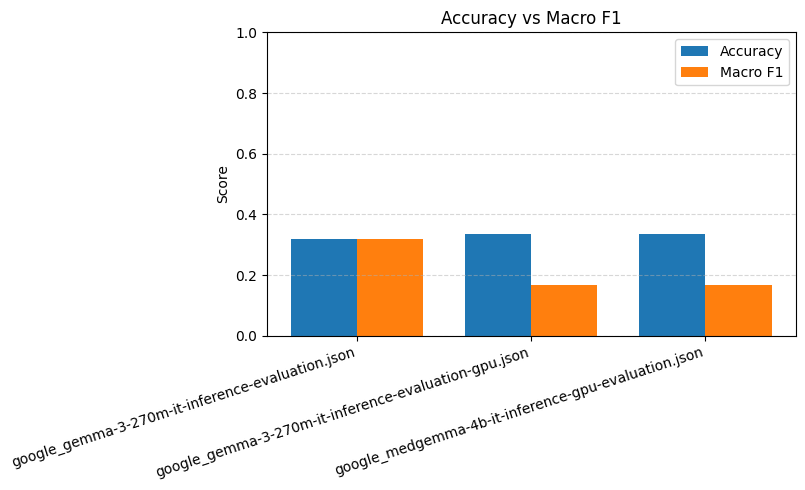

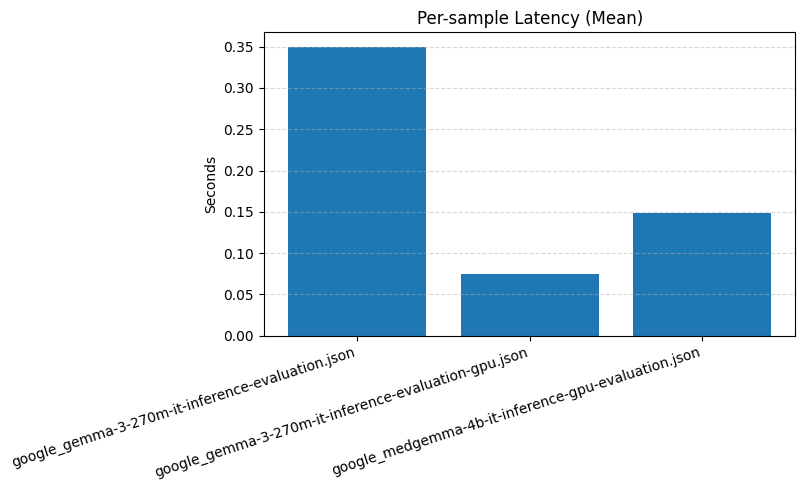

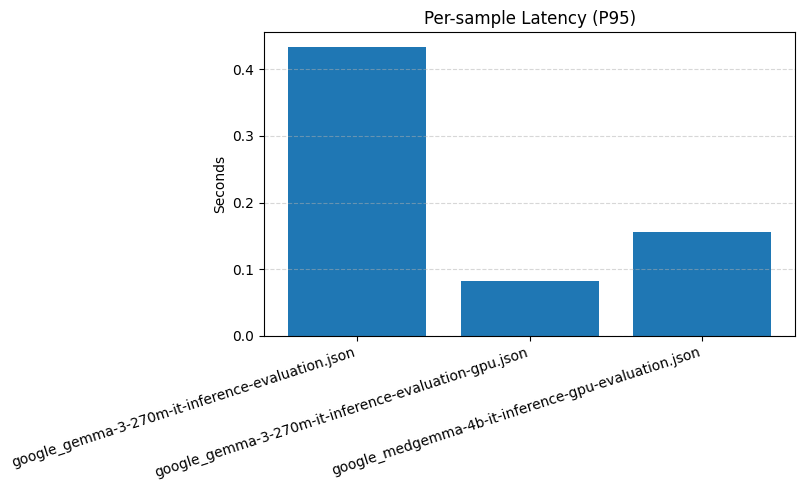

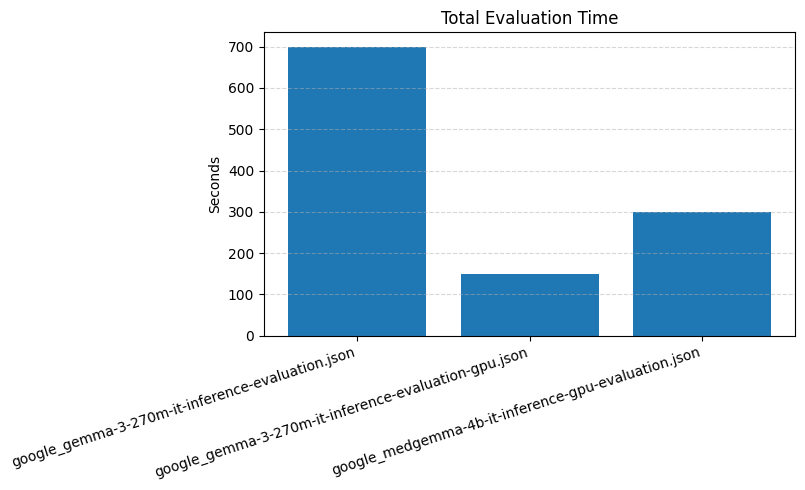

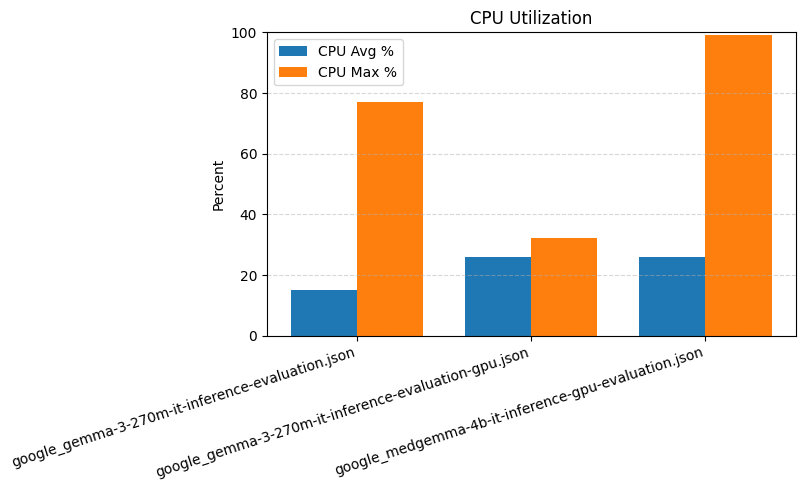

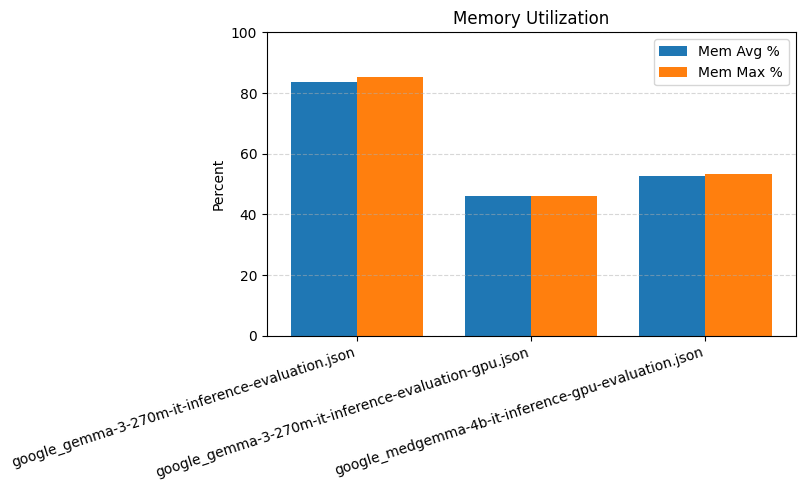

In [8]:
def safe(d, k, default=float("nan")):
    return d.get(k, default)

summary = []
perclass_frames = []
for r in runs:
    res = r.get("resource_stats", {})
    summary.append({
        "model": r["_name"],
        "accuracy": safe(r, "accuracy"),
        "macro_f1": safe(r, "macro_f1"),
        "latency_mean_s": safe(r, "per_sample_latency_sec_mean"),
        "latency_p95_s": safe(r, "per_sample_latency_sec_p95"),
        "total_time_s": safe(r, "total_time_sec"),
        "cpu_avg_%": safe(res, "cpu_percent_avg"),
        "cpu_max_%": safe(res, "cpu_percent_max"),
        "mem_avg_%": safe(res, "mem_percent_avg"),
        "mem_max_%": safe(res, "mem_percent_max"),
    })
    rep = r.get("report", "")
    df_rep = parse_classification_report(rep) if rep else pd.DataFrame()
    if not df_rep.empty:
        df_rep.insert(0, "model", r["_name"])
        perclass_frames.append(df_rep)

df = pd.DataFrame(summary)
df_perclass = pd.concat(perclass_frames, ignore_index=True) if perclass_frames else pd.DataFrame()

# Keep axis order stable across plots
labels = list(df["model"])
x = range(len(labels))
width = 0.38

# ---- Plot 1: Accuracy vs Macro F1 ----
plt.figure(figsize=(8, 5))
plt.bar([i - width/2 for i in x], df["accuracy"], width=width, label="Accuracy")
plt.bar([i + width/2 for i in x], df["macro_f1"], width=width, label="Macro F1")
plt.xticks(list(x), labels, rotation=18, ha="right")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Accuracy vs Macro F1")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot 2: Per-sample Latency (Mean) ----
plt.figure(figsize=(8, 5))
plt.bar(labels, df["latency_mean_s"])
plt.ylabel("Seconds")
plt.title("Per-sample Latency (Mean)")
plt.xticks(rotation=18, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ---- Plot 3: Per-sample Latency (P95) ----
plt.figure(figsize=(8, 5))
plt.bar(labels, df["latency_p95_s"])
plt.ylabel("Seconds")
plt.title("Per-sample Latency (P95)")
plt.xticks(rotation=18, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ---- Plot 4: Total Evaluation Time ----
plt.figure(figsize=(8, 5))
plt.bar(labels, df["total_time_s"])
plt.ylabel("Seconds")
plt.title("Total Evaluation Time")
plt.xticks(rotation=18, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ---- Plot 5: CPU Utilization (Avg/Max) ----
plt.figure(figsize=(8, 5))
plt.bar([i - width/2 for i in x], df["cpu_avg_%"], width=width, label="CPU Avg %")
plt.bar([i + width/2 for i in x], df["cpu_max_%"], width=width, label="CPU Max %")
plt.xticks(list(x), labels, rotation=18, ha="right")
plt.ylabel("Percent")
plt.ylim(0, 100)
plt.title("CPU Utilization")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot 6: Memory Utilization (Avg/Max) ----
plt.figure(figsize=(8, 5))
plt.bar([i - width/2 for i in x], df["mem_avg_%"], width=width, label="Mem Avg %")
plt.bar([i + width/2 for i in x], df["mem_max_%"], width=width, label="Mem Max %")
plt.xticks(list(x), labels, rotation=18, ha="right")
plt.ylabel("Percent")
plt.ylim(0, 100)
plt.title("Memory Utilization")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
